# Demo 3: 特征贡献（PSSM 维度对比）

参考 AcrPred：从 full experiment 结果中筛选 Ablation_RPSSM_110/310/710/1110，绘制 AUC（或 AUPRC）mean ± std 柱状图。

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from proteinbert import load_anticrispr_with_ids, load_feature_cache, attach_pssm_features

PLOT_DPI = 800
plt.rcParams.update({'figure.dpi': PLOT_DPI, 'savefig.dpi': PLOT_DPI})

PROJECT_ROOT = '/home/nemophila/projects/protein_bert'
WORK_ROOT = os.environ.get('PSSM_WORK_ROOT', '/home/nemophila/data/pssm_work')
BENCHMARKS_DIR = os.path.join(PROJECT_ROOT, 'anticrispr_benchmarks')
FEAT_DIR = os.path.join(WORK_ROOT, 'features')
SEED = 22

2026-03-18 23:43:24.990835: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0


In [2]:
def load_pssm(dim_str):
    parquet_p = os.path.join(FEAT_DIR, f'pssm_features_{dim_str}.parquet')
    csv_p = os.path.join(FEAT_DIR, f'pssm_features_{dim_str}.csv')
    cp = parquet_p if os.path.exists(parquet_p) else csv_p
    return load_feature_cache(cp)

def run_pssm_ablation(dim_str, seed):
    train_base, test_base = load_anticrispr_with_ids(BENCHMARKS_DIR, benchmark_name='anticrispr_binary')
    if dim_str == '110':
        feat_df, feat_cols = load_pssm('310')
        feat_cols = feat_cols[:110]
    else:
        feat_df, feat_cols = load_pssm(dim_str)
    train_df = attach_pssm_features(train_base, feat_df, feat_cols)
    test_df = attach_pssm_features(test_base, feat_df, feat_cols)
    sub_tr, sub_va = train_test_split(train_df, test_size=0.1, stratify=train_df['label'], random_state=seed)
    y_tr = sub_tr['label'].astype(int).to_numpy()
    y_te = test_df['label'].astype(int).to_numpy()
    scaler = StandardScaler().fit(sub_tr[feat_cols].to_numpy(dtype=np.float32))
    X_tr = scaler.transform(sub_tr[feat_cols].to_numpy(dtype=np.float32))
    X_te = scaler.transform(test_df[feat_cols].to_numpy(dtype=np.float32))
    clf = LogisticRegression(max_iter=2000, solver='liblinear', random_state=seed)
    clf.fit(X_tr, y_tr)
    te_prob = clf.predict_proba(X_te)[:, 1]
    return {'AUC': roc_auc_score(y_te, te_prob), 'AUPRC': average_precision_score(y_te, te_prob)}

dims_used = [110, 310, 710, 1110]
auc_vals = []
auprc_vals = []
for d in dims_used:
    m = run_pssm_ablation(str(d), SEED)
    auc_vals.append(m['AUC'])
    auprc_vals.append(m['AUPRC'])
    print(f'PSSM {d}D: AUC={m["AUC"]:.4f}, AUPRC={m["AUPRC"]:.4f}')

PSSM 110D: AUC=0.7479, AUPRC=0.2760
PSSM 310D: AUC=0.7596, AUPRC=0.2562
PSSM 710D: AUC=0.8027, AUPRC=0.3741
PSSM 1110D: AUC=0.8649, AUPRC=0.4662


## PSSM 维度对比：AUC 与 AUPRC

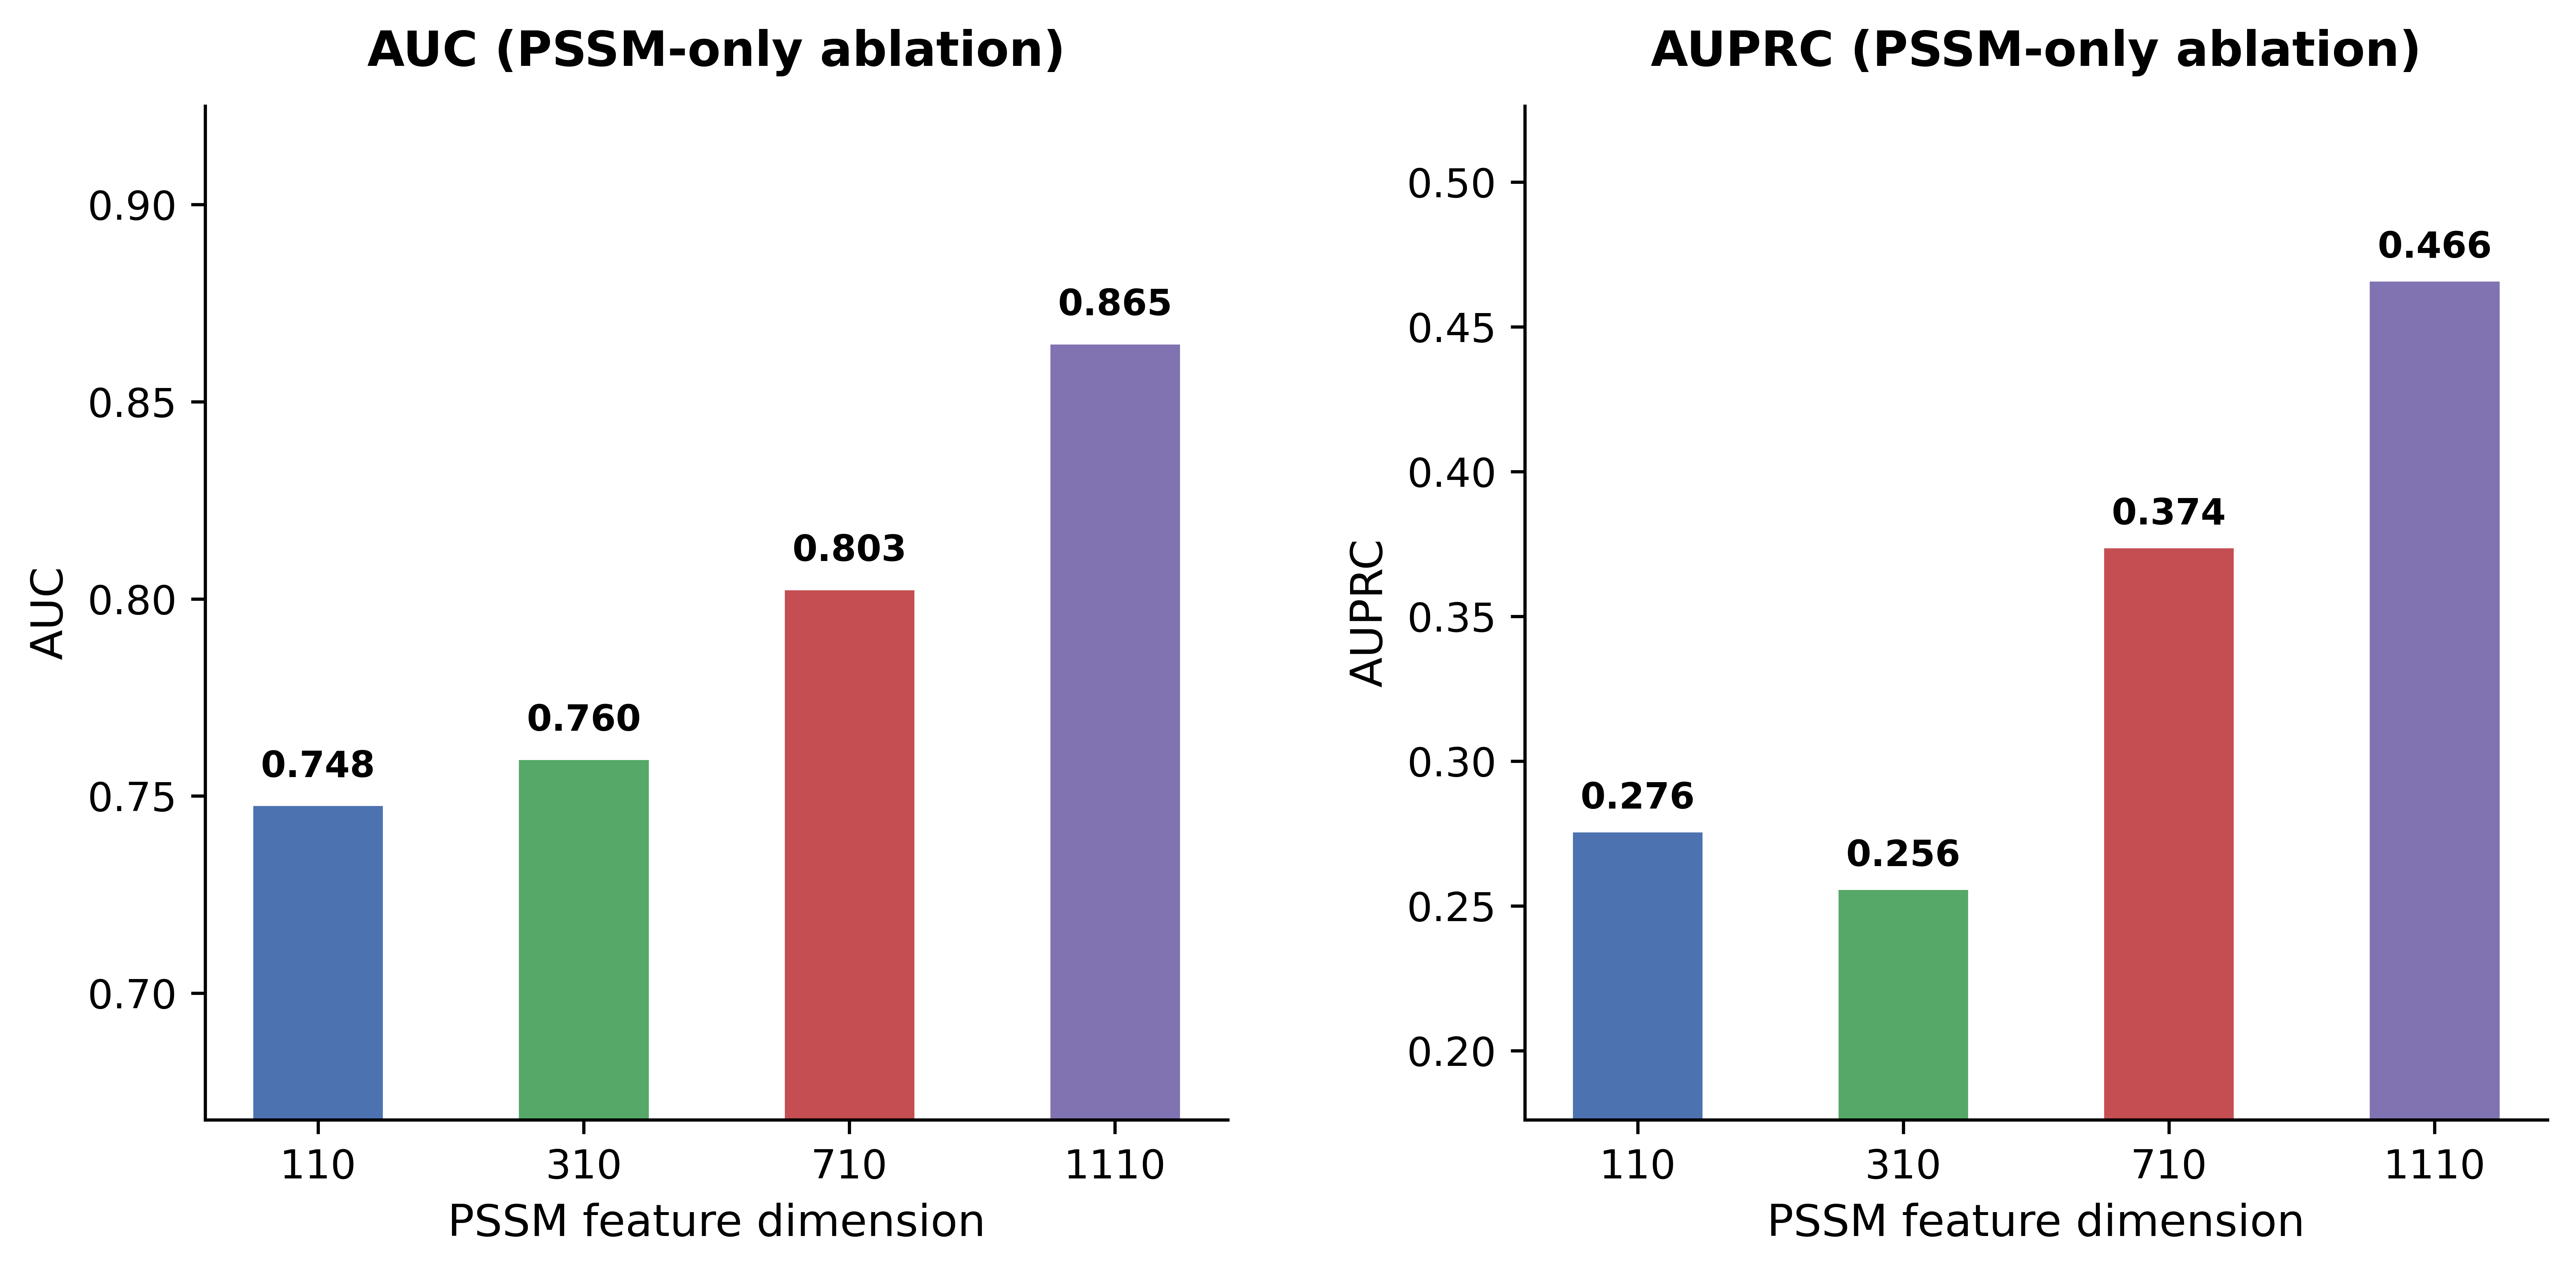

In [3]:
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
width = 0.5
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
x = np.arange(len(dims_used))

for ax, vals, ylabel, title in [
    (axes[0], auc_vals, 'AUC', 'AUC (PSSM-only ablation)'),
    (axes[1], auprc_vals, 'AUPRC', 'AUPRC (PSSM-only ablation)'),
]:
    bars = ax.bar(x, vals, width=width, color=colors, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ymin = max(0, min(vals) - 0.08)
    ymax = max(vals) + 0.06
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d) for d in dims_used], fontsize=10)
    ax.set_xlabel('PSSM feature dimension', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout(w_pad=3)
plt.savefig(os.path.join(PROJECT_ROOT, 'notebooks', 'pssm_ablation_bar.png'), dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

## PSSM 1110 维特征 t-SNE（仅 PSSM，不融合 ProteinBERT）

单独使用 PSSM 1110 维特征（与 Ablation PSSM-only 一致），按训练集 / 验证集 / 测试集分别做 t-SNE，各画一张图，按 Acr / Non-Acr 着色。

In [4]:
from sklearn.manifold import TSNE

PSSM_DIM = '1110'
VALID_SEED = SEED
parquet_path = os.path.join(FEAT_DIR, f'pssm_features_{PSSM_DIM}.parquet')
csv_path = os.path.join(FEAT_DIR, f'pssm_features_{PSSM_DIM}.csv')
cache_path = parquet_path if os.path.exists(parquet_path) else csv_path
if not os.path.exists(cache_path):
    raise FileNotFoundError(f'PSSM cache not found: {cache_path}')

train_df, test_df = load_anticrispr_with_ids(BENCHMARKS_DIR, benchmark_name='anticrispr_binary')
sub_train, sub_valid = train_test_split(
    train_df, test_size=0.1, stratify=train_df['label'], random_state=VALID_SEED
)
feat_df, feat_cols = load_feature_cache(cache_path)
train_with_pssm = attach_pssm_features(sub_train, feat_df, feat_cols)
valid_with_pssm = attach_pssm_features(sub_valid, feat_df, feat_cols)
test_with_pssm = attach_pssm_features(test_df, feat_df, feat_cols)

X_train = train_with_pssm[feat_cols].to_numpy(dtype=np.float32)
X_valid = valid_with_pssm[feat_cols].to_numpy(dtype=np.float32)
X_test = test_with_pssm[feat_cols].to_numpy(dtype=np.float32)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)
y_train = train_with_pssm['label'].astype(int).to_numpy()
y_valid = valid_with_pssm['label'].astype(int).to_numpy()
y_test = test_with_pssm['label'].astype(int).to_numpy()
splits = {'train': (X_train_s, y_train), 'valid': (X_valid_s, y_valid), 'test': (X_test_s, y_test)}
for name, (X, y) in splits.items():
    print(f'{name}: X {X.shape}, y {y.shape}')

train: X (996, 1110), y (996,)
valid: X (111, 1110), y (111,)
test: X (286, 1110), y (286,)


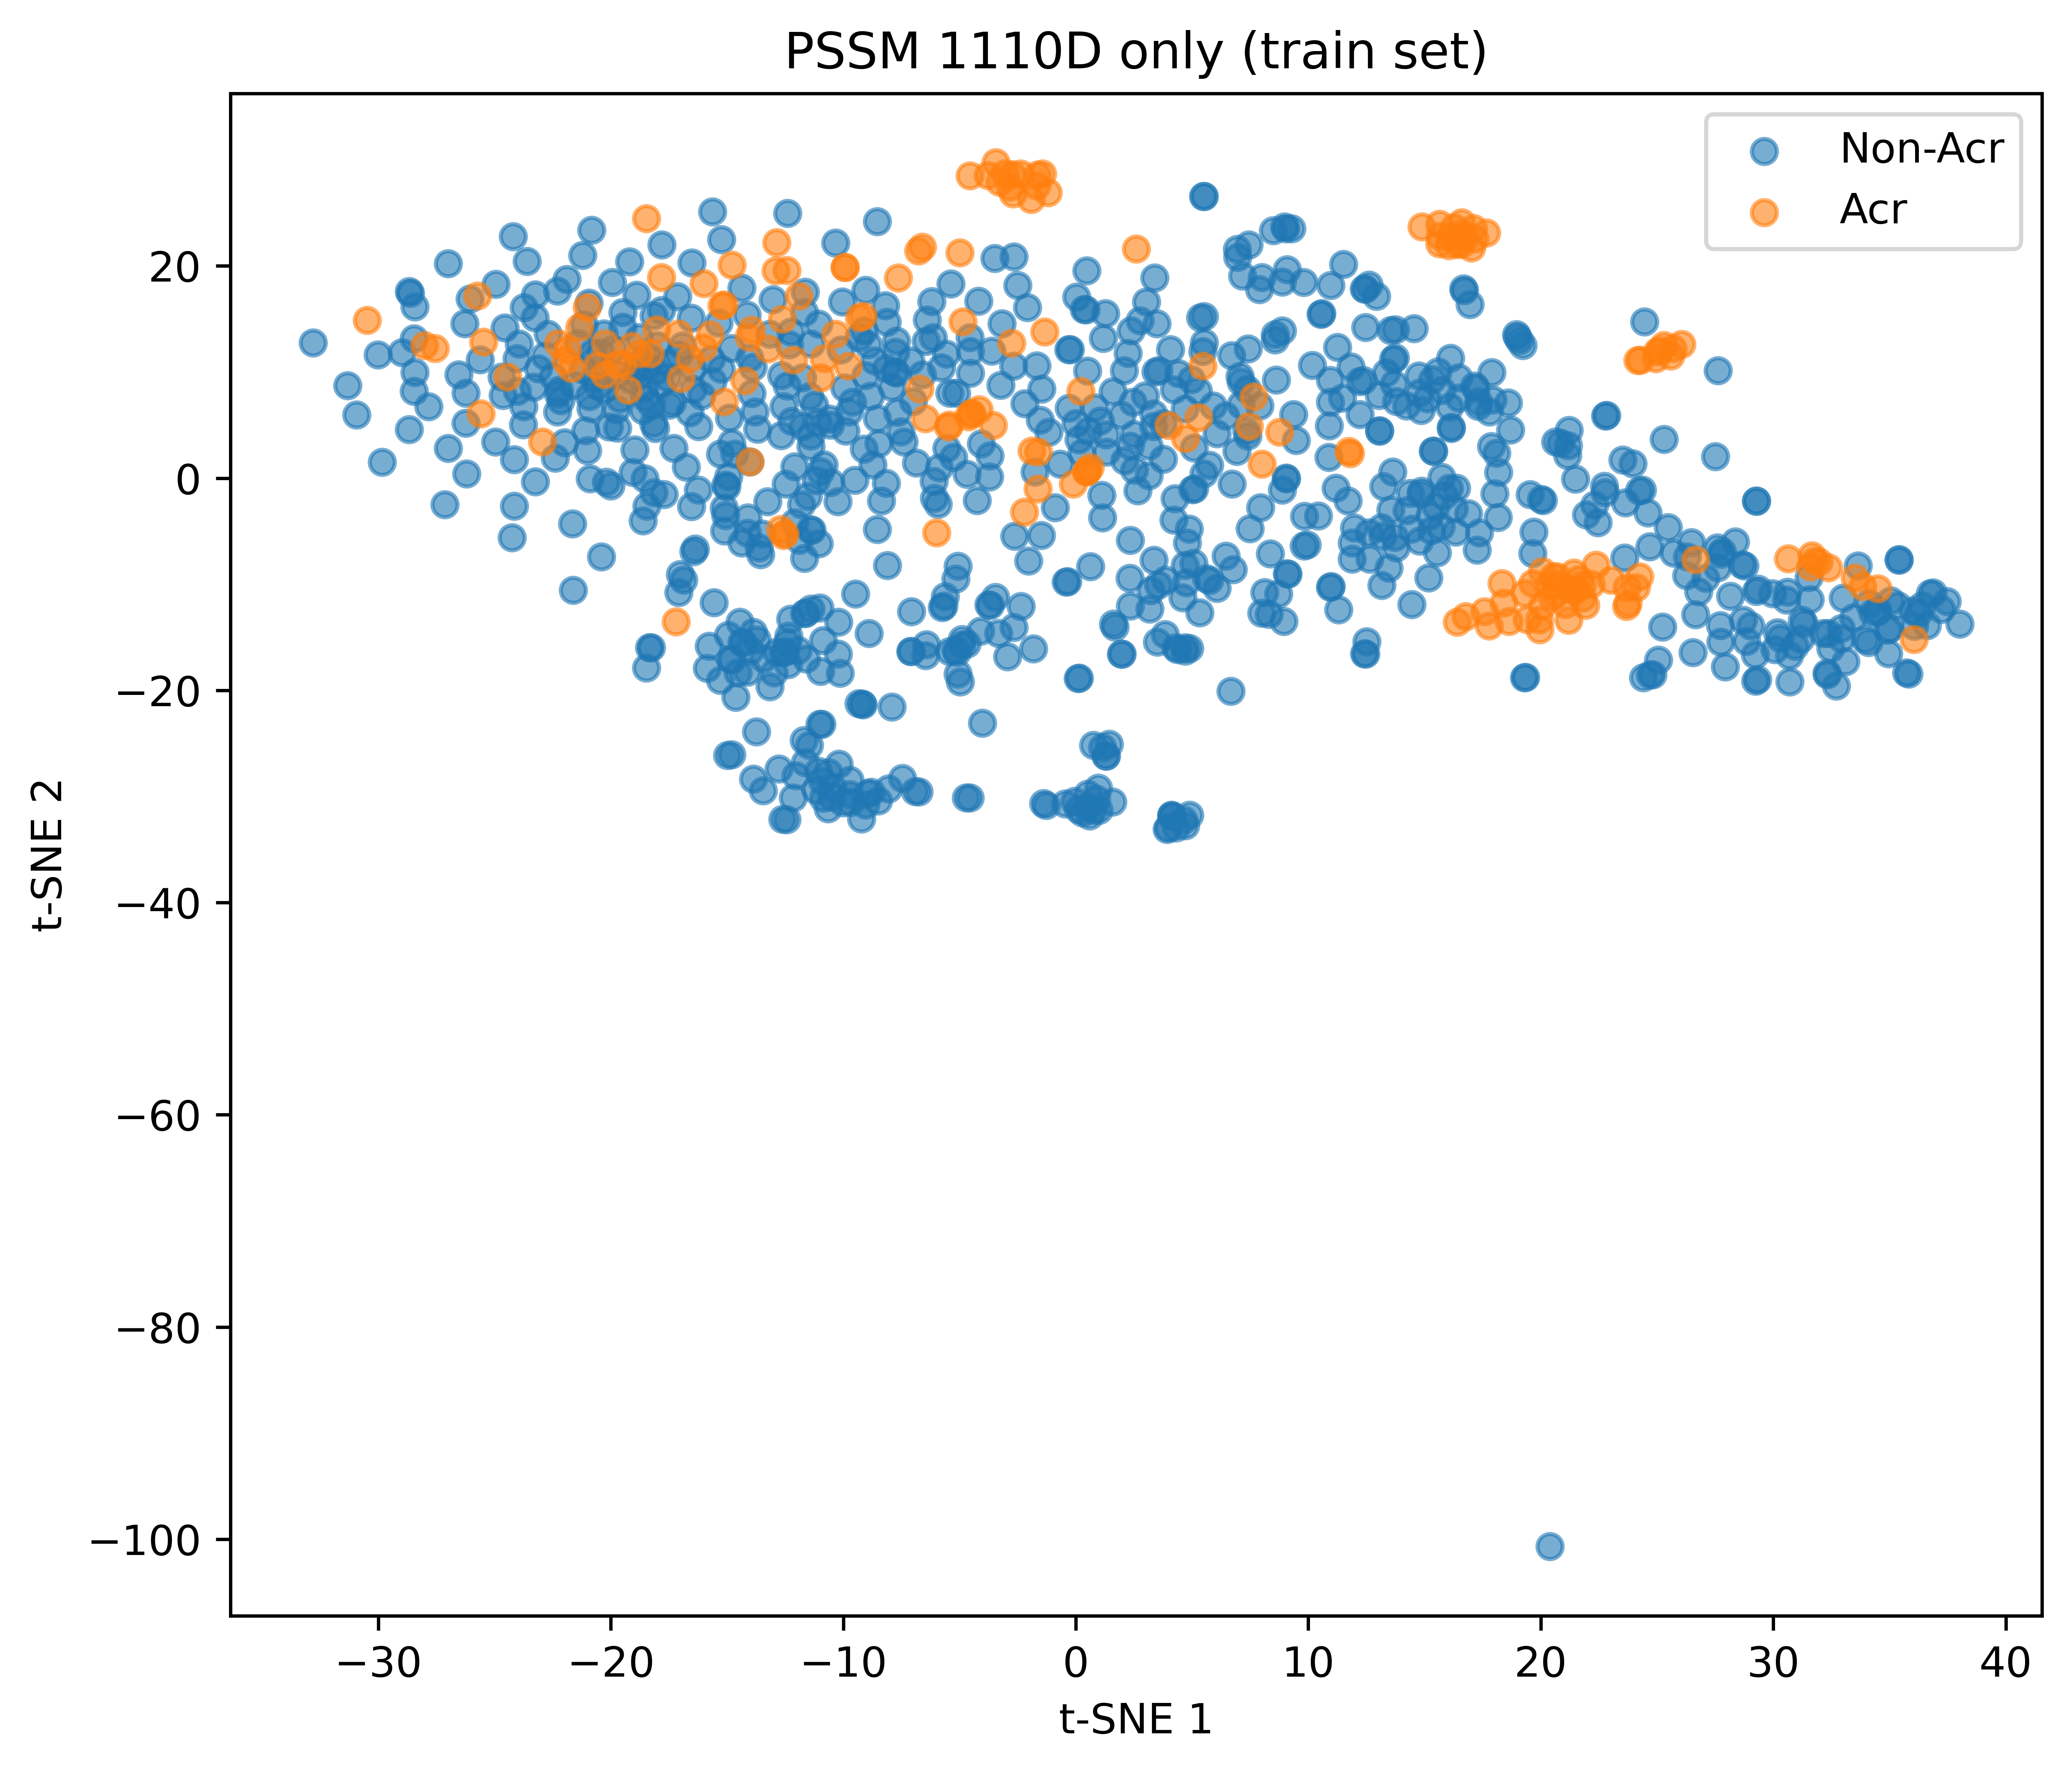

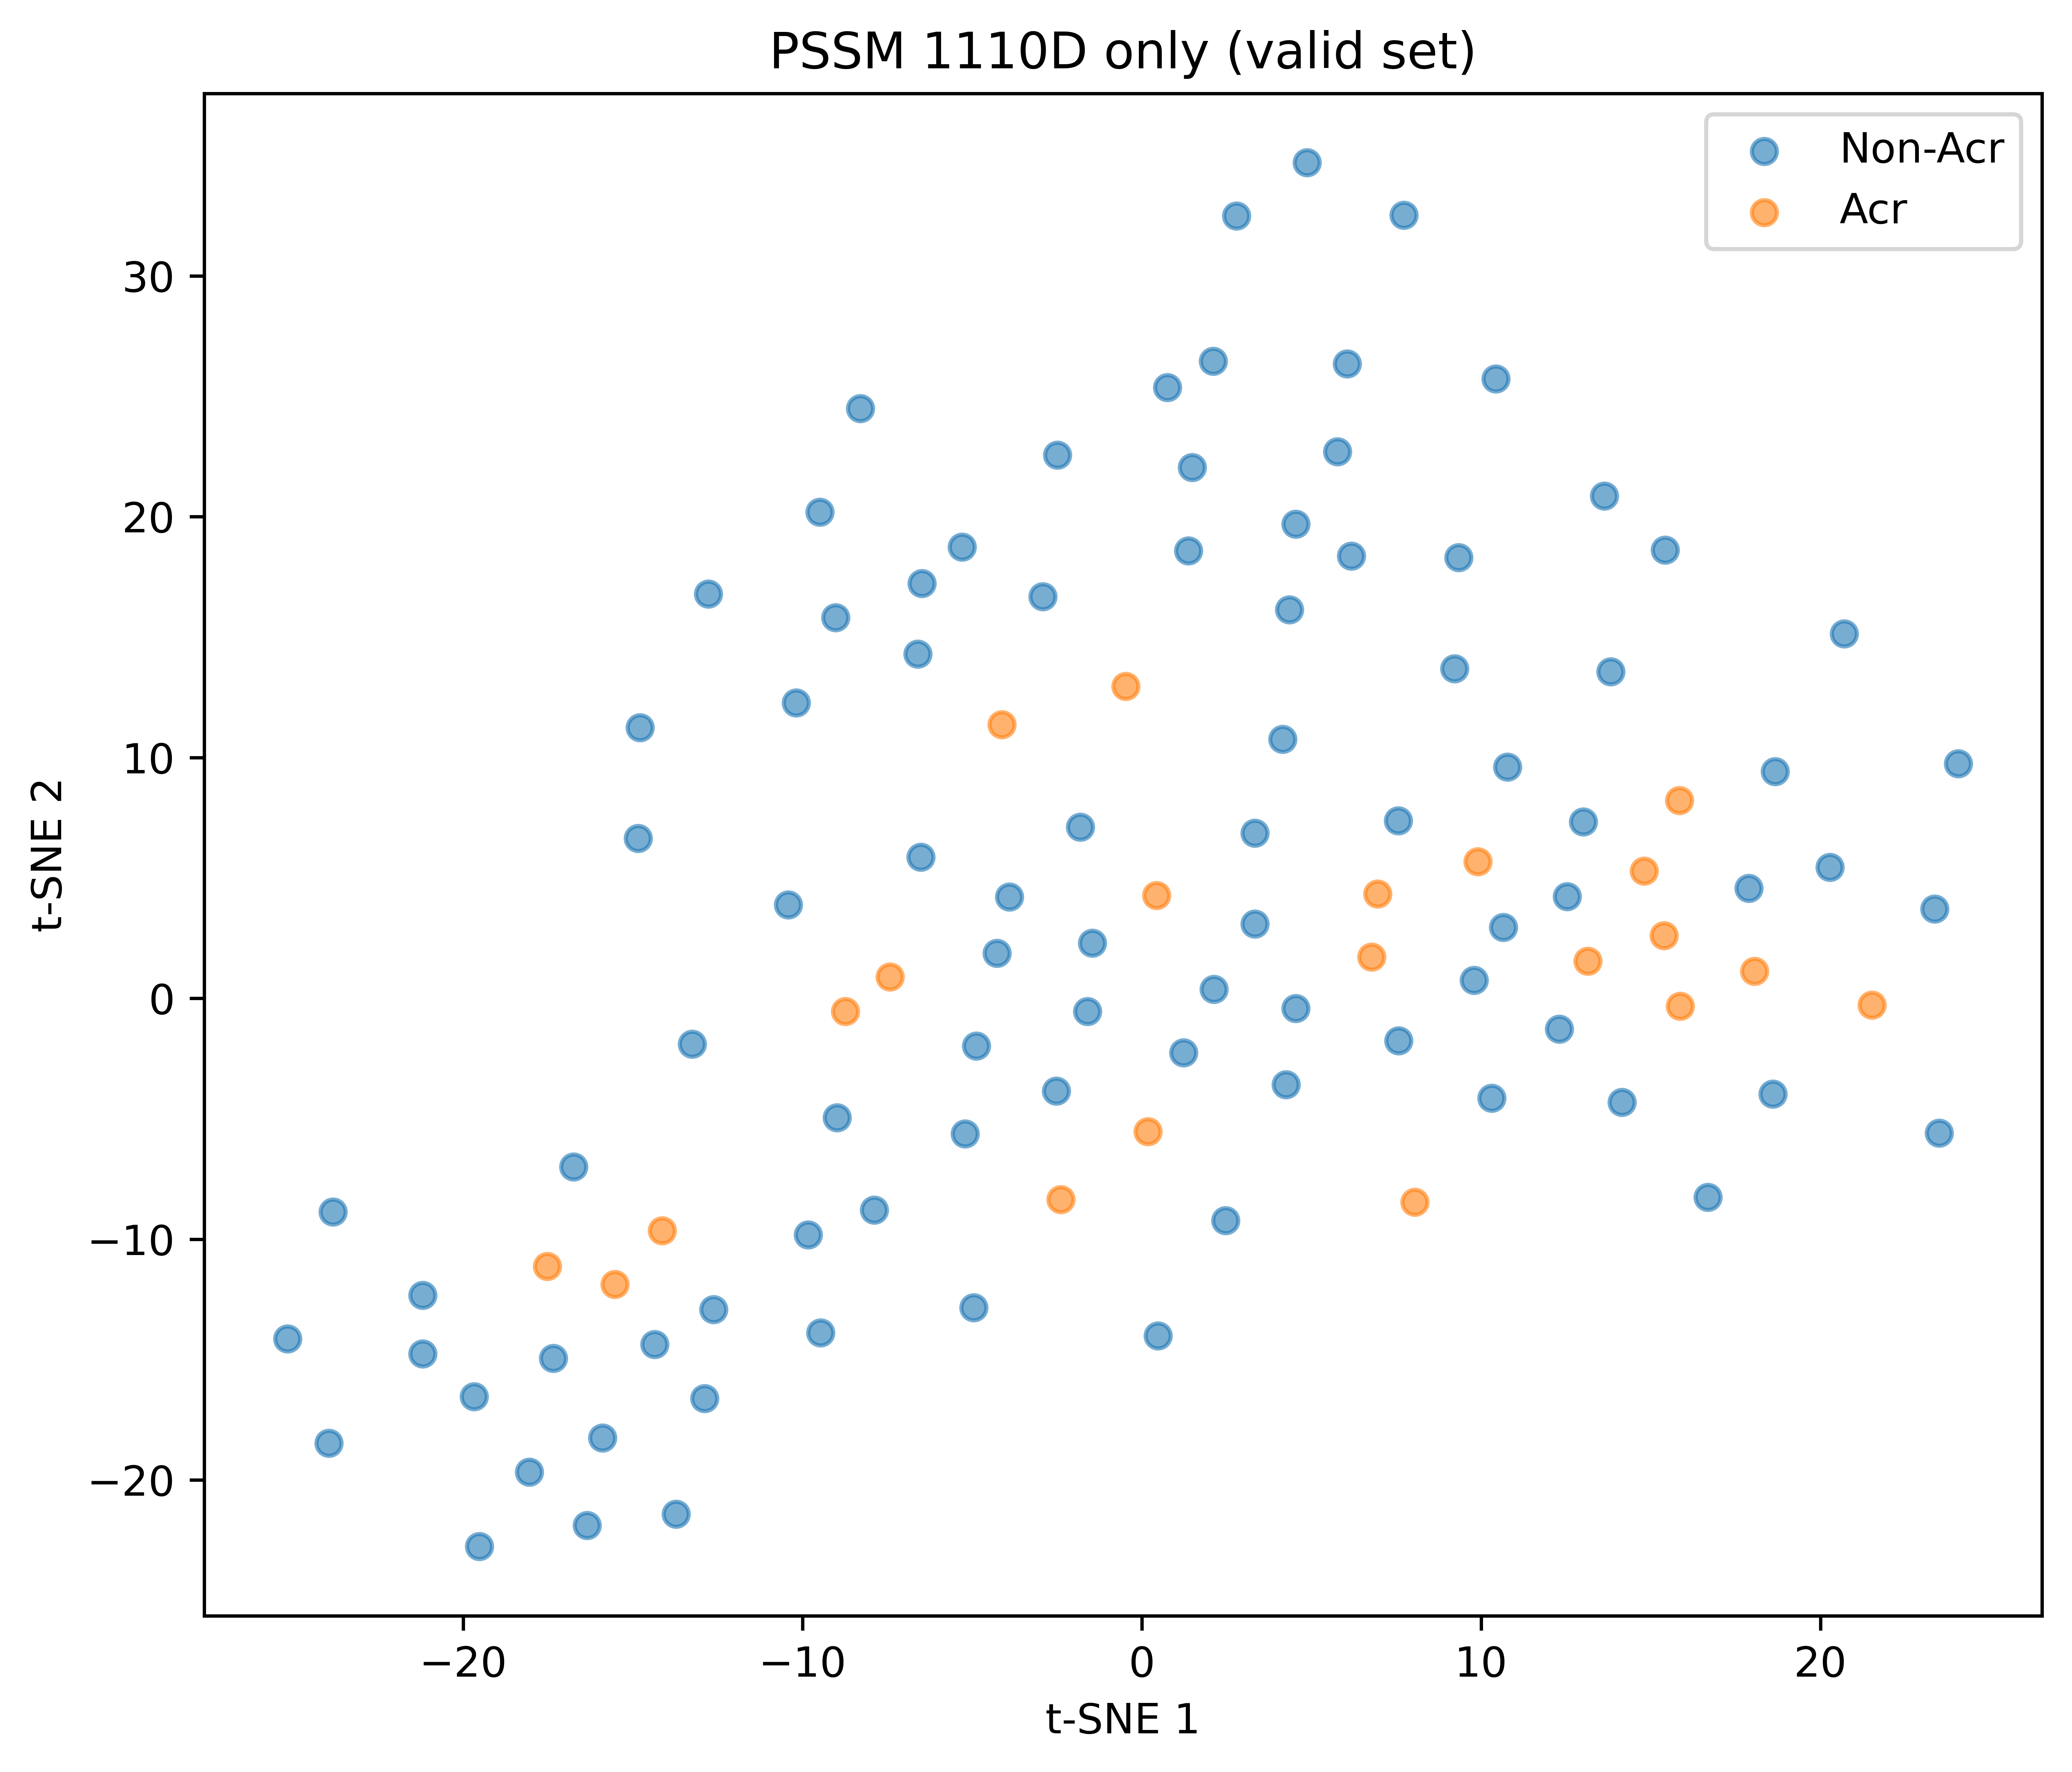

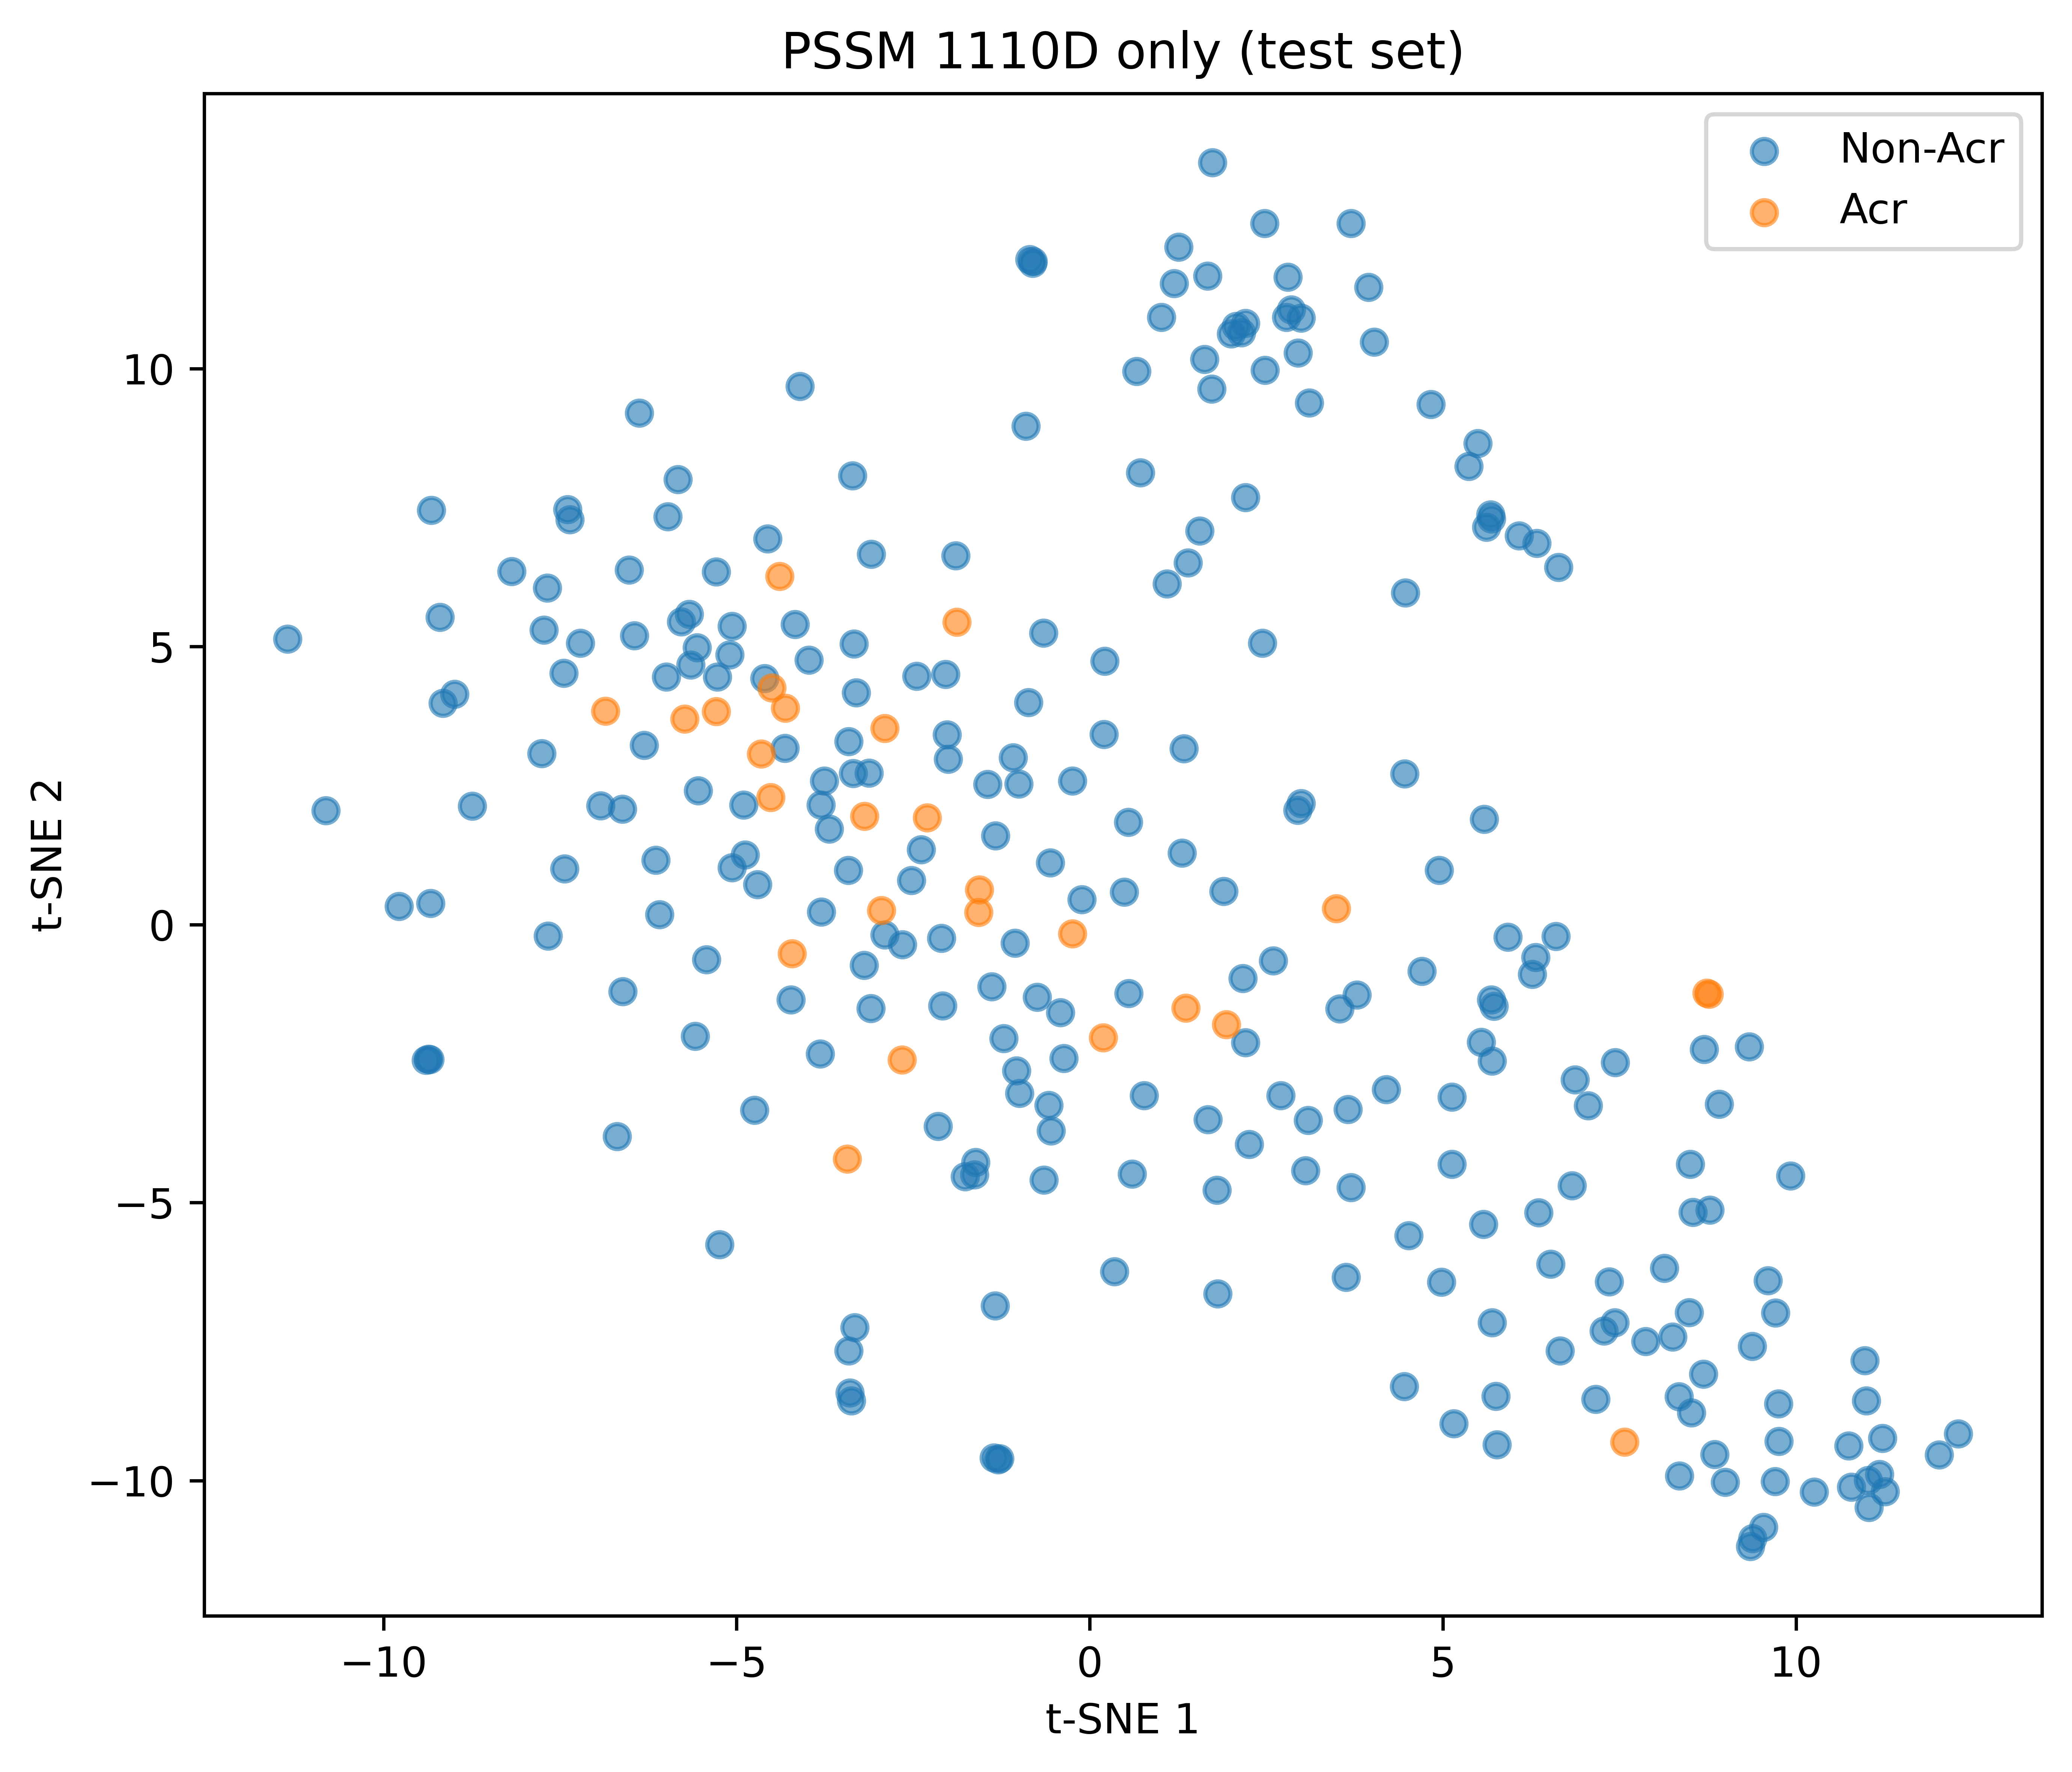

In [5]:
for split_name in ('train', 'valid', 'test'):
    X_s, y_s = splits[split_name]
    tsne = TSNE(n_components=2, random_state=22, perplexity=min(30, max(5, len(X_s)//4)))
    emb_2d = tsne.fit_transform(X_s)
    fig, ax = plt.subplots(figsize=(7, 6))
    for l, name in [(0, 'Non-Acr'), (1, 'Acr')]:
        mask = y_s == l
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], alpha=0.6, label=name)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend()
    ax.set_title(f'PSSM {PSSM_DIM}D only ({split_name} set)')
    plt.tight_layout()
    plt.show()

## PSSM 1110 维特征 UMAP（仅 PSSM，不融合 ProteinBERT）

与上方 t-SNE 相同的数据，使用 UMAP 进行降维可视化，UMAP 更好地保留全局结构。

/home/nemophila/miniconda3/envs/tf24pb/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nemophila/miniconda3/envs/tf24pb/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


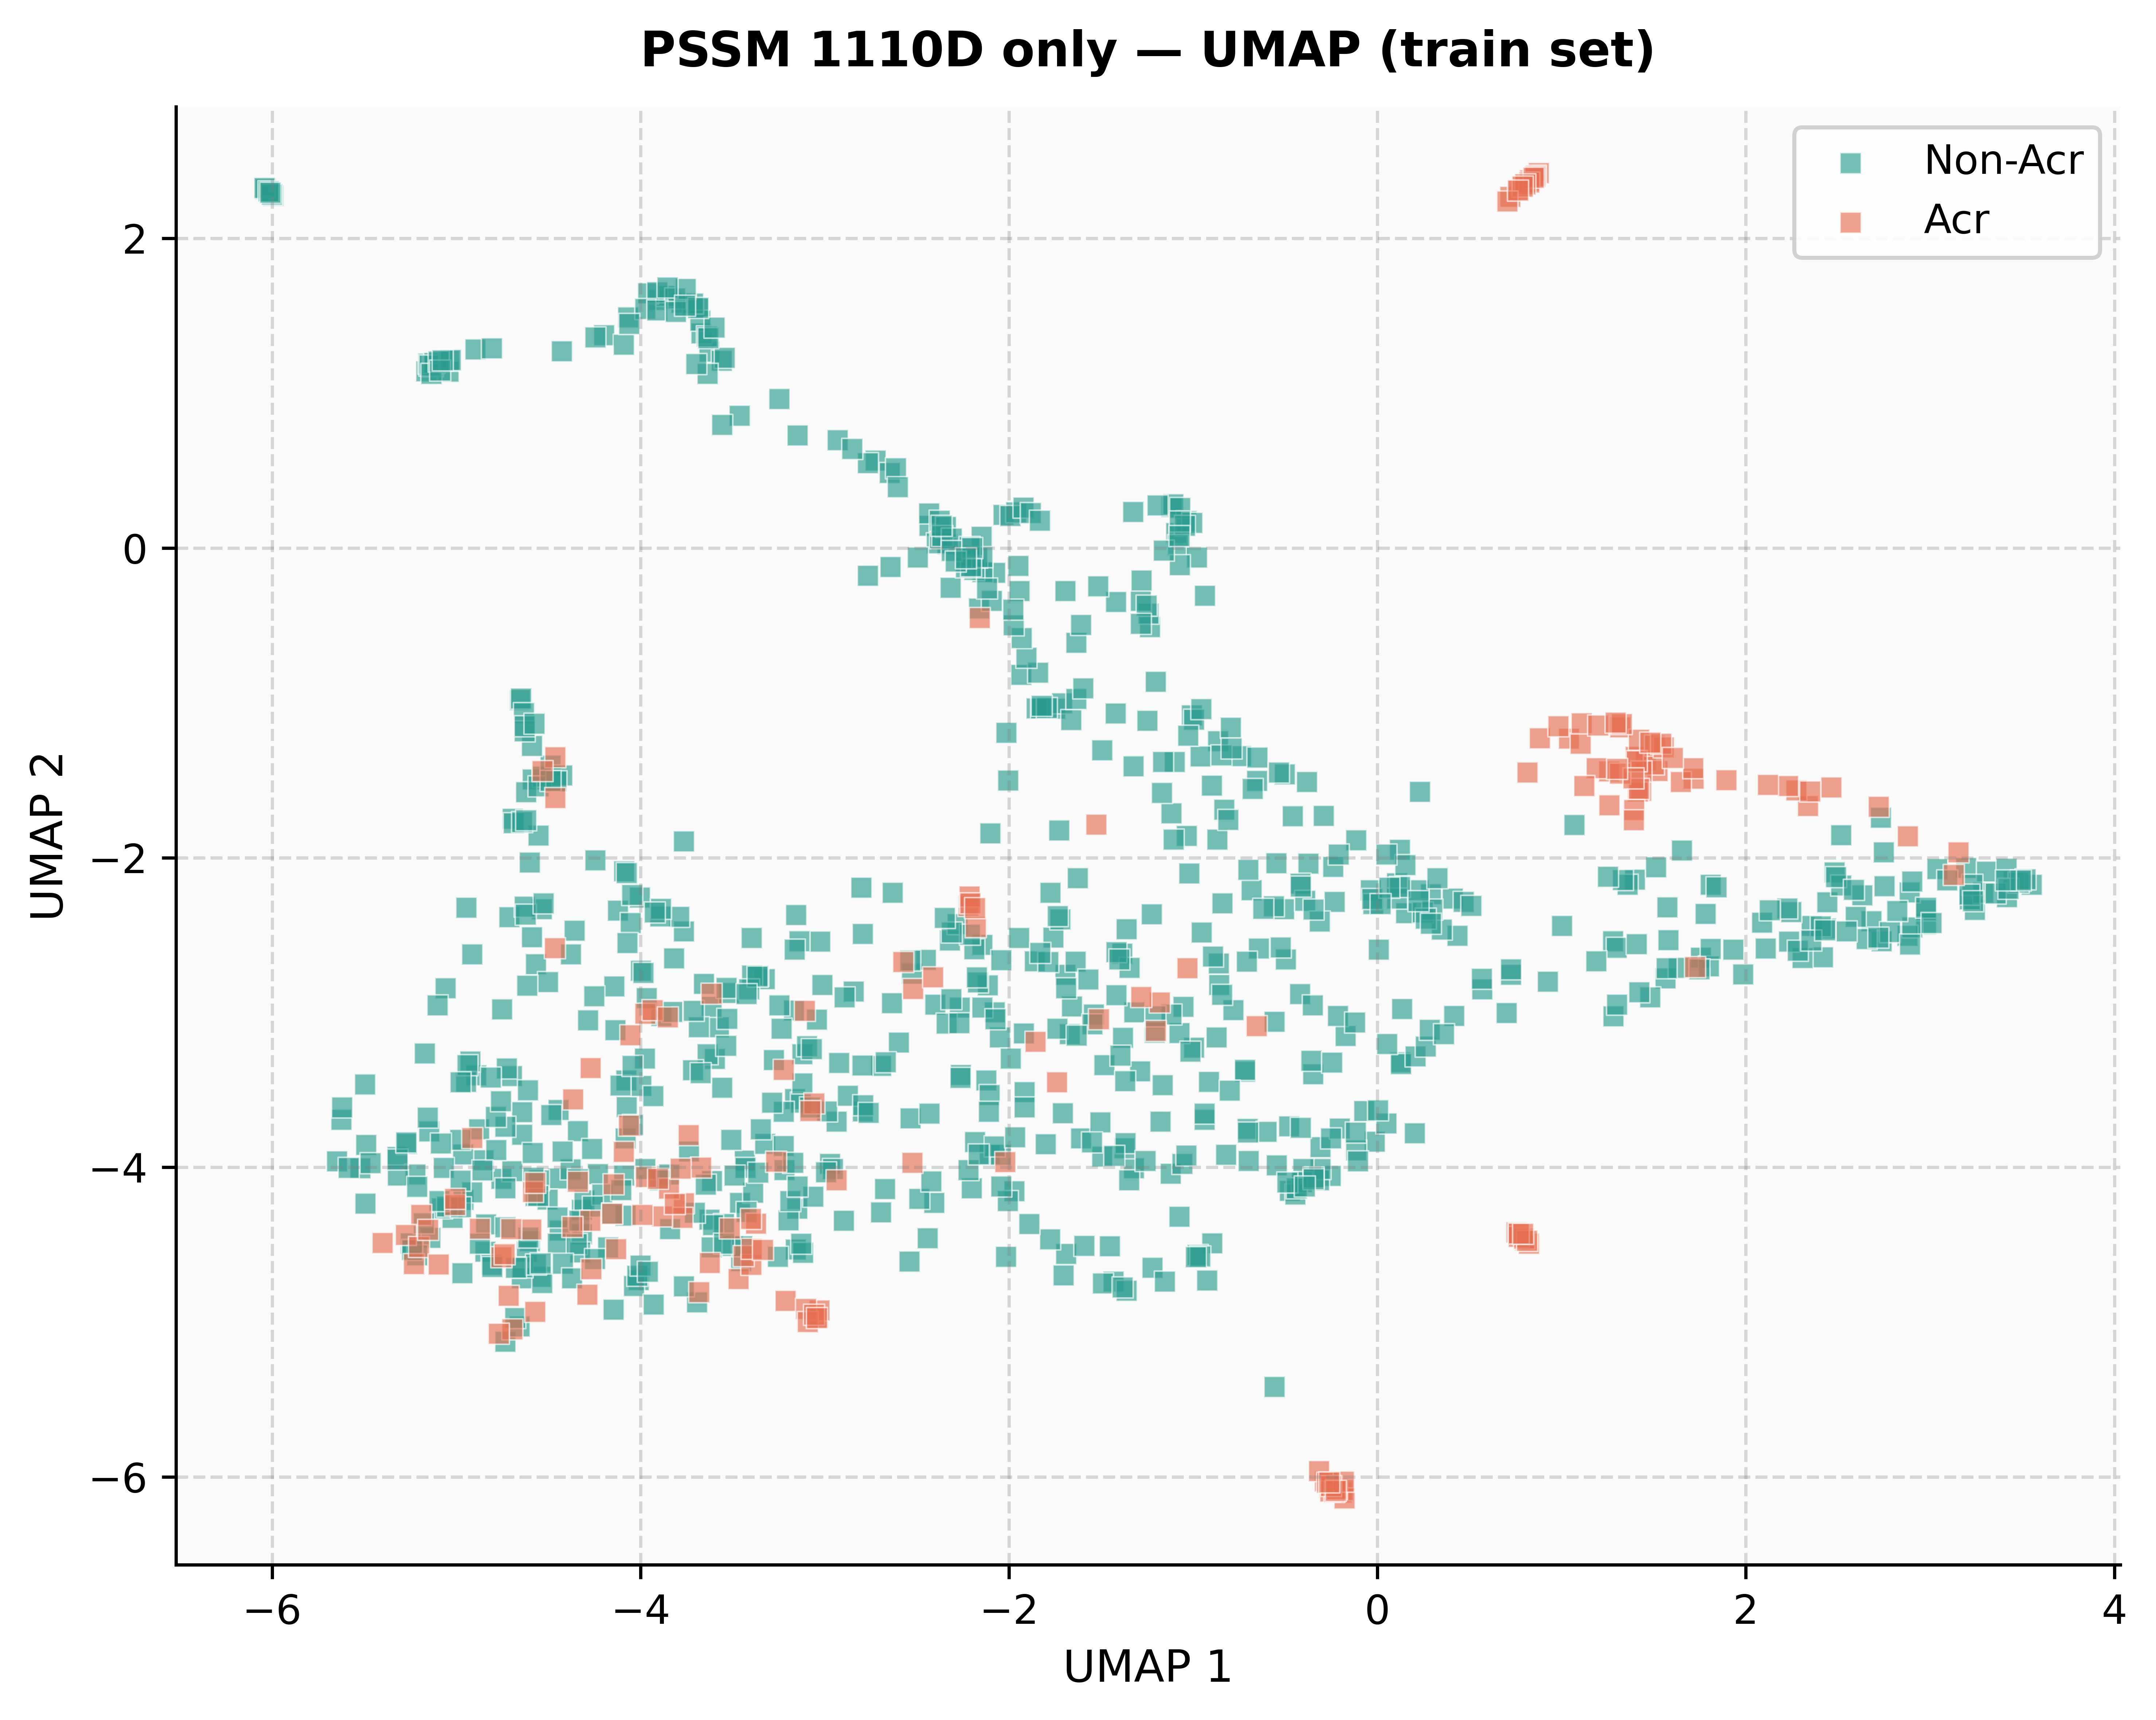

/home/nemophila/miniconda3/envs/tf24pb/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


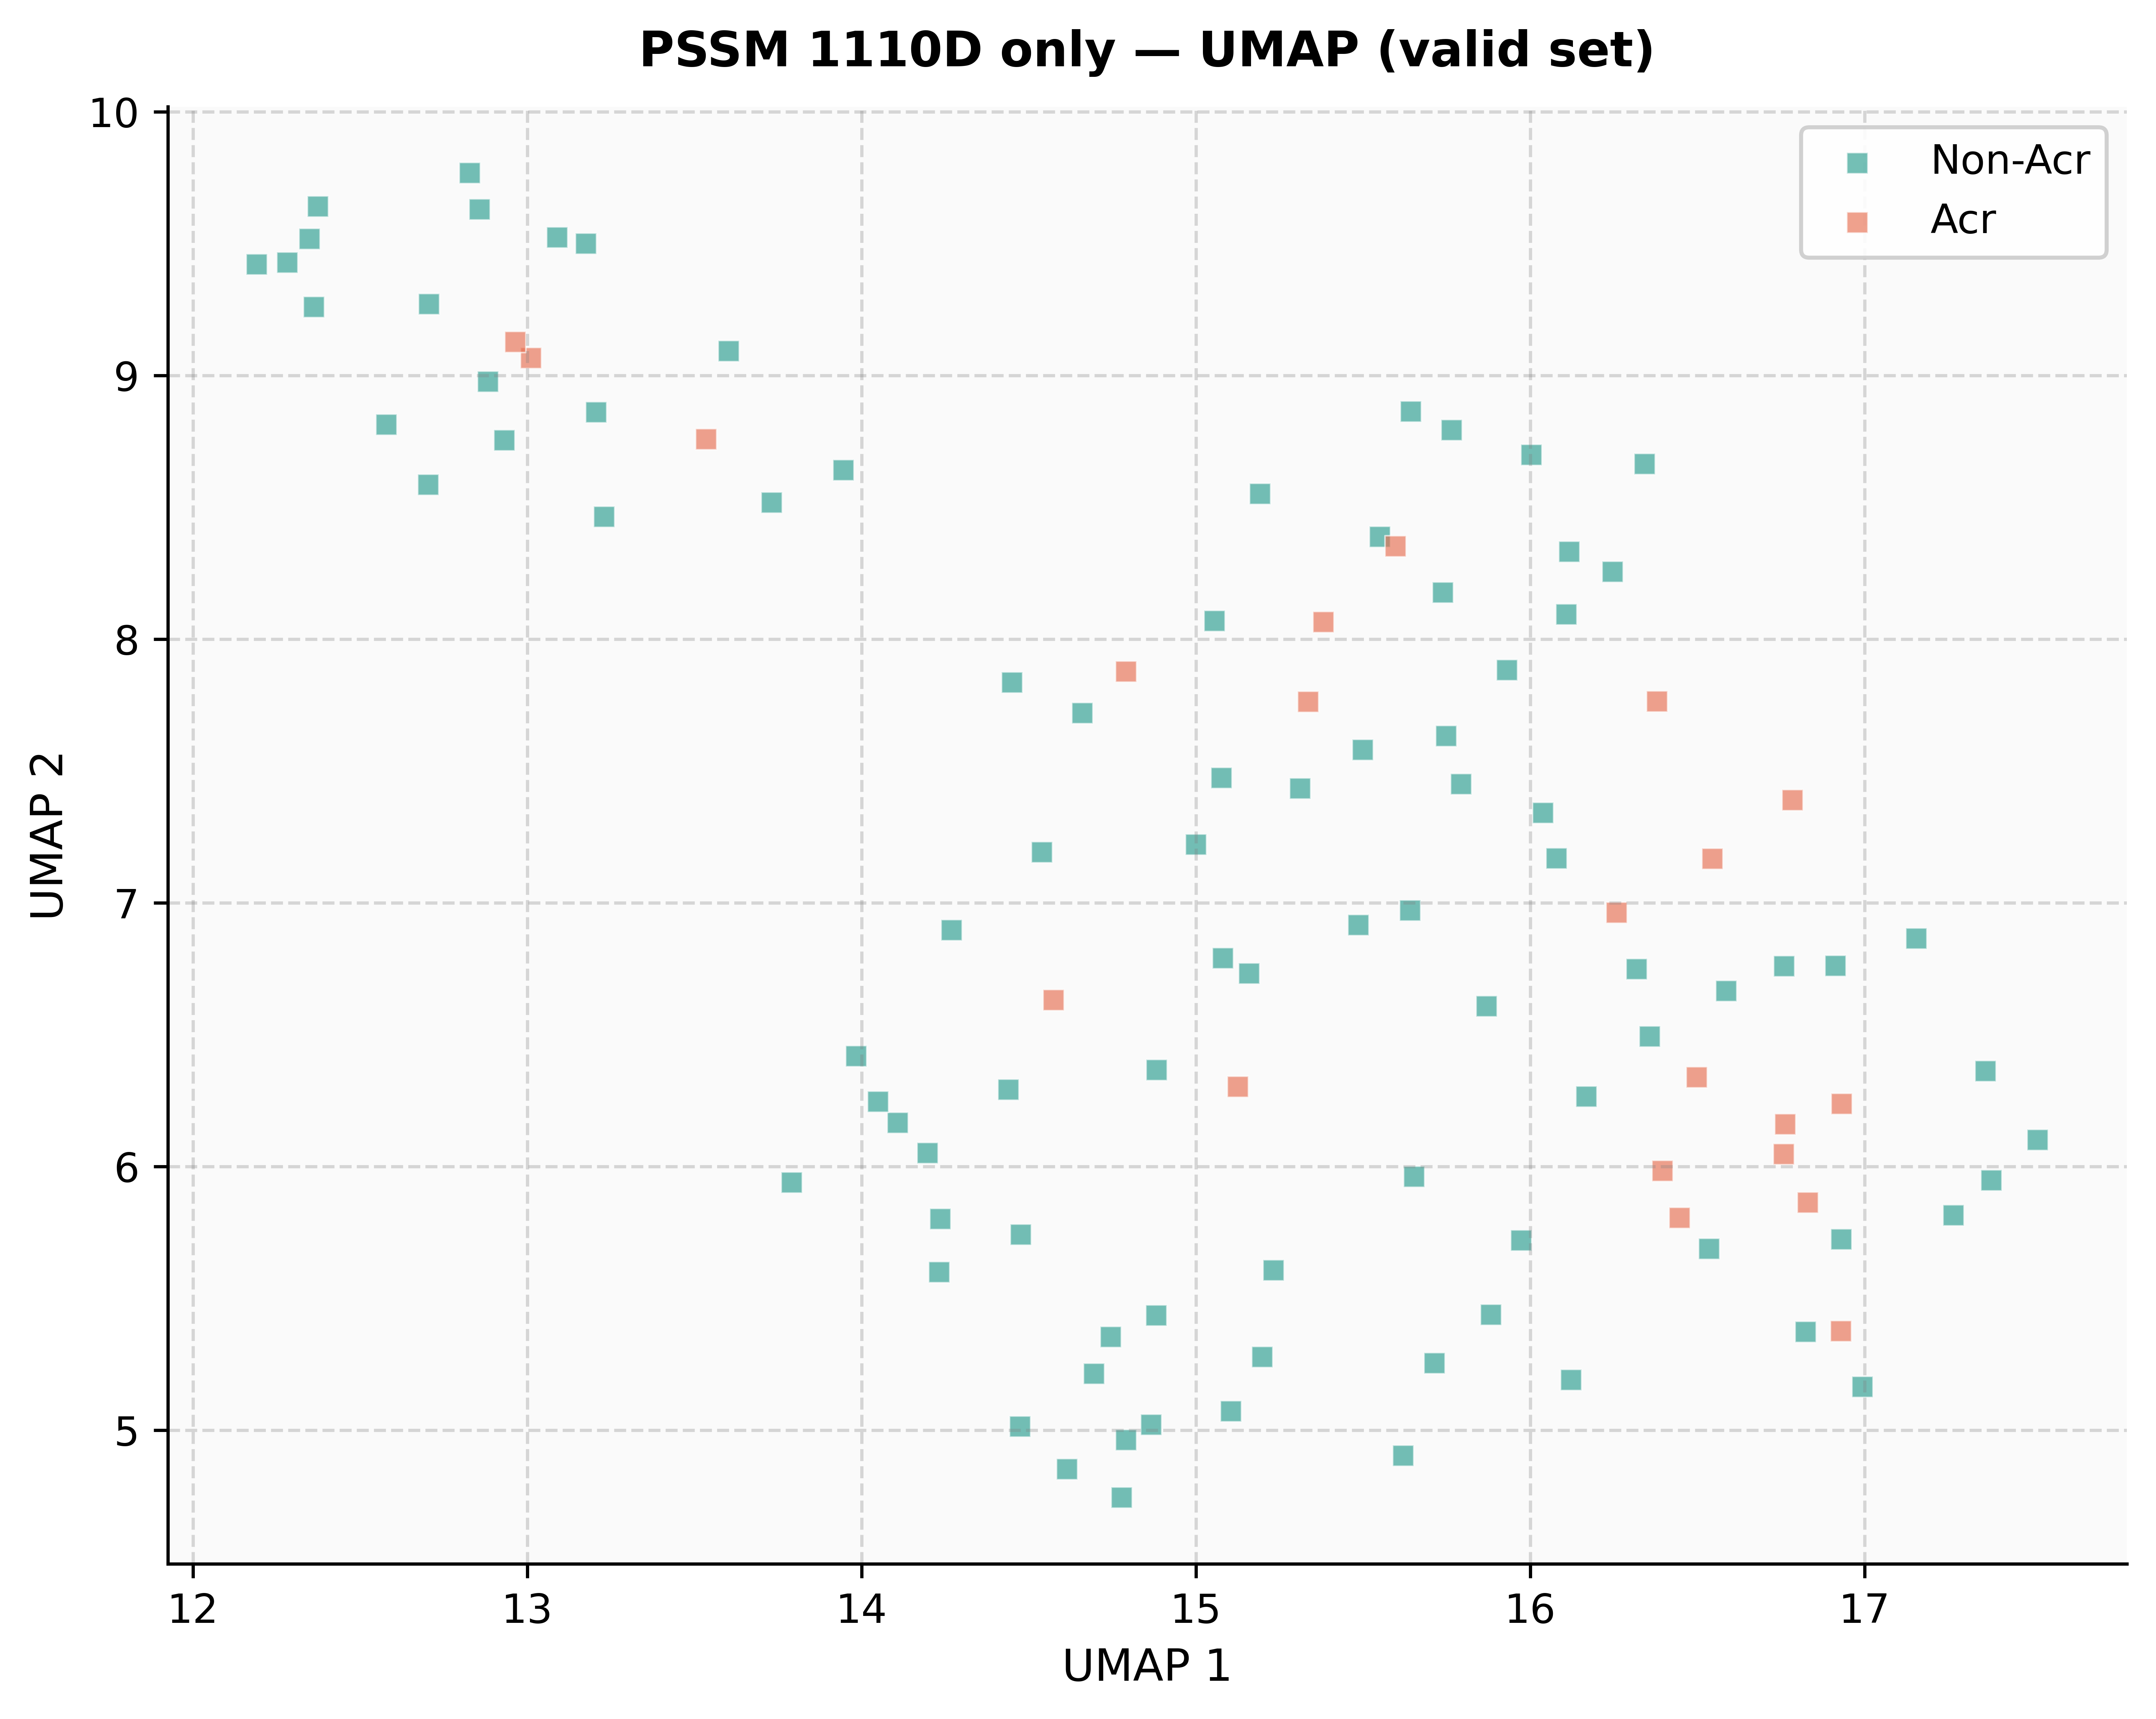

/home/nemophila/miniconda3/envs/tf24pb/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


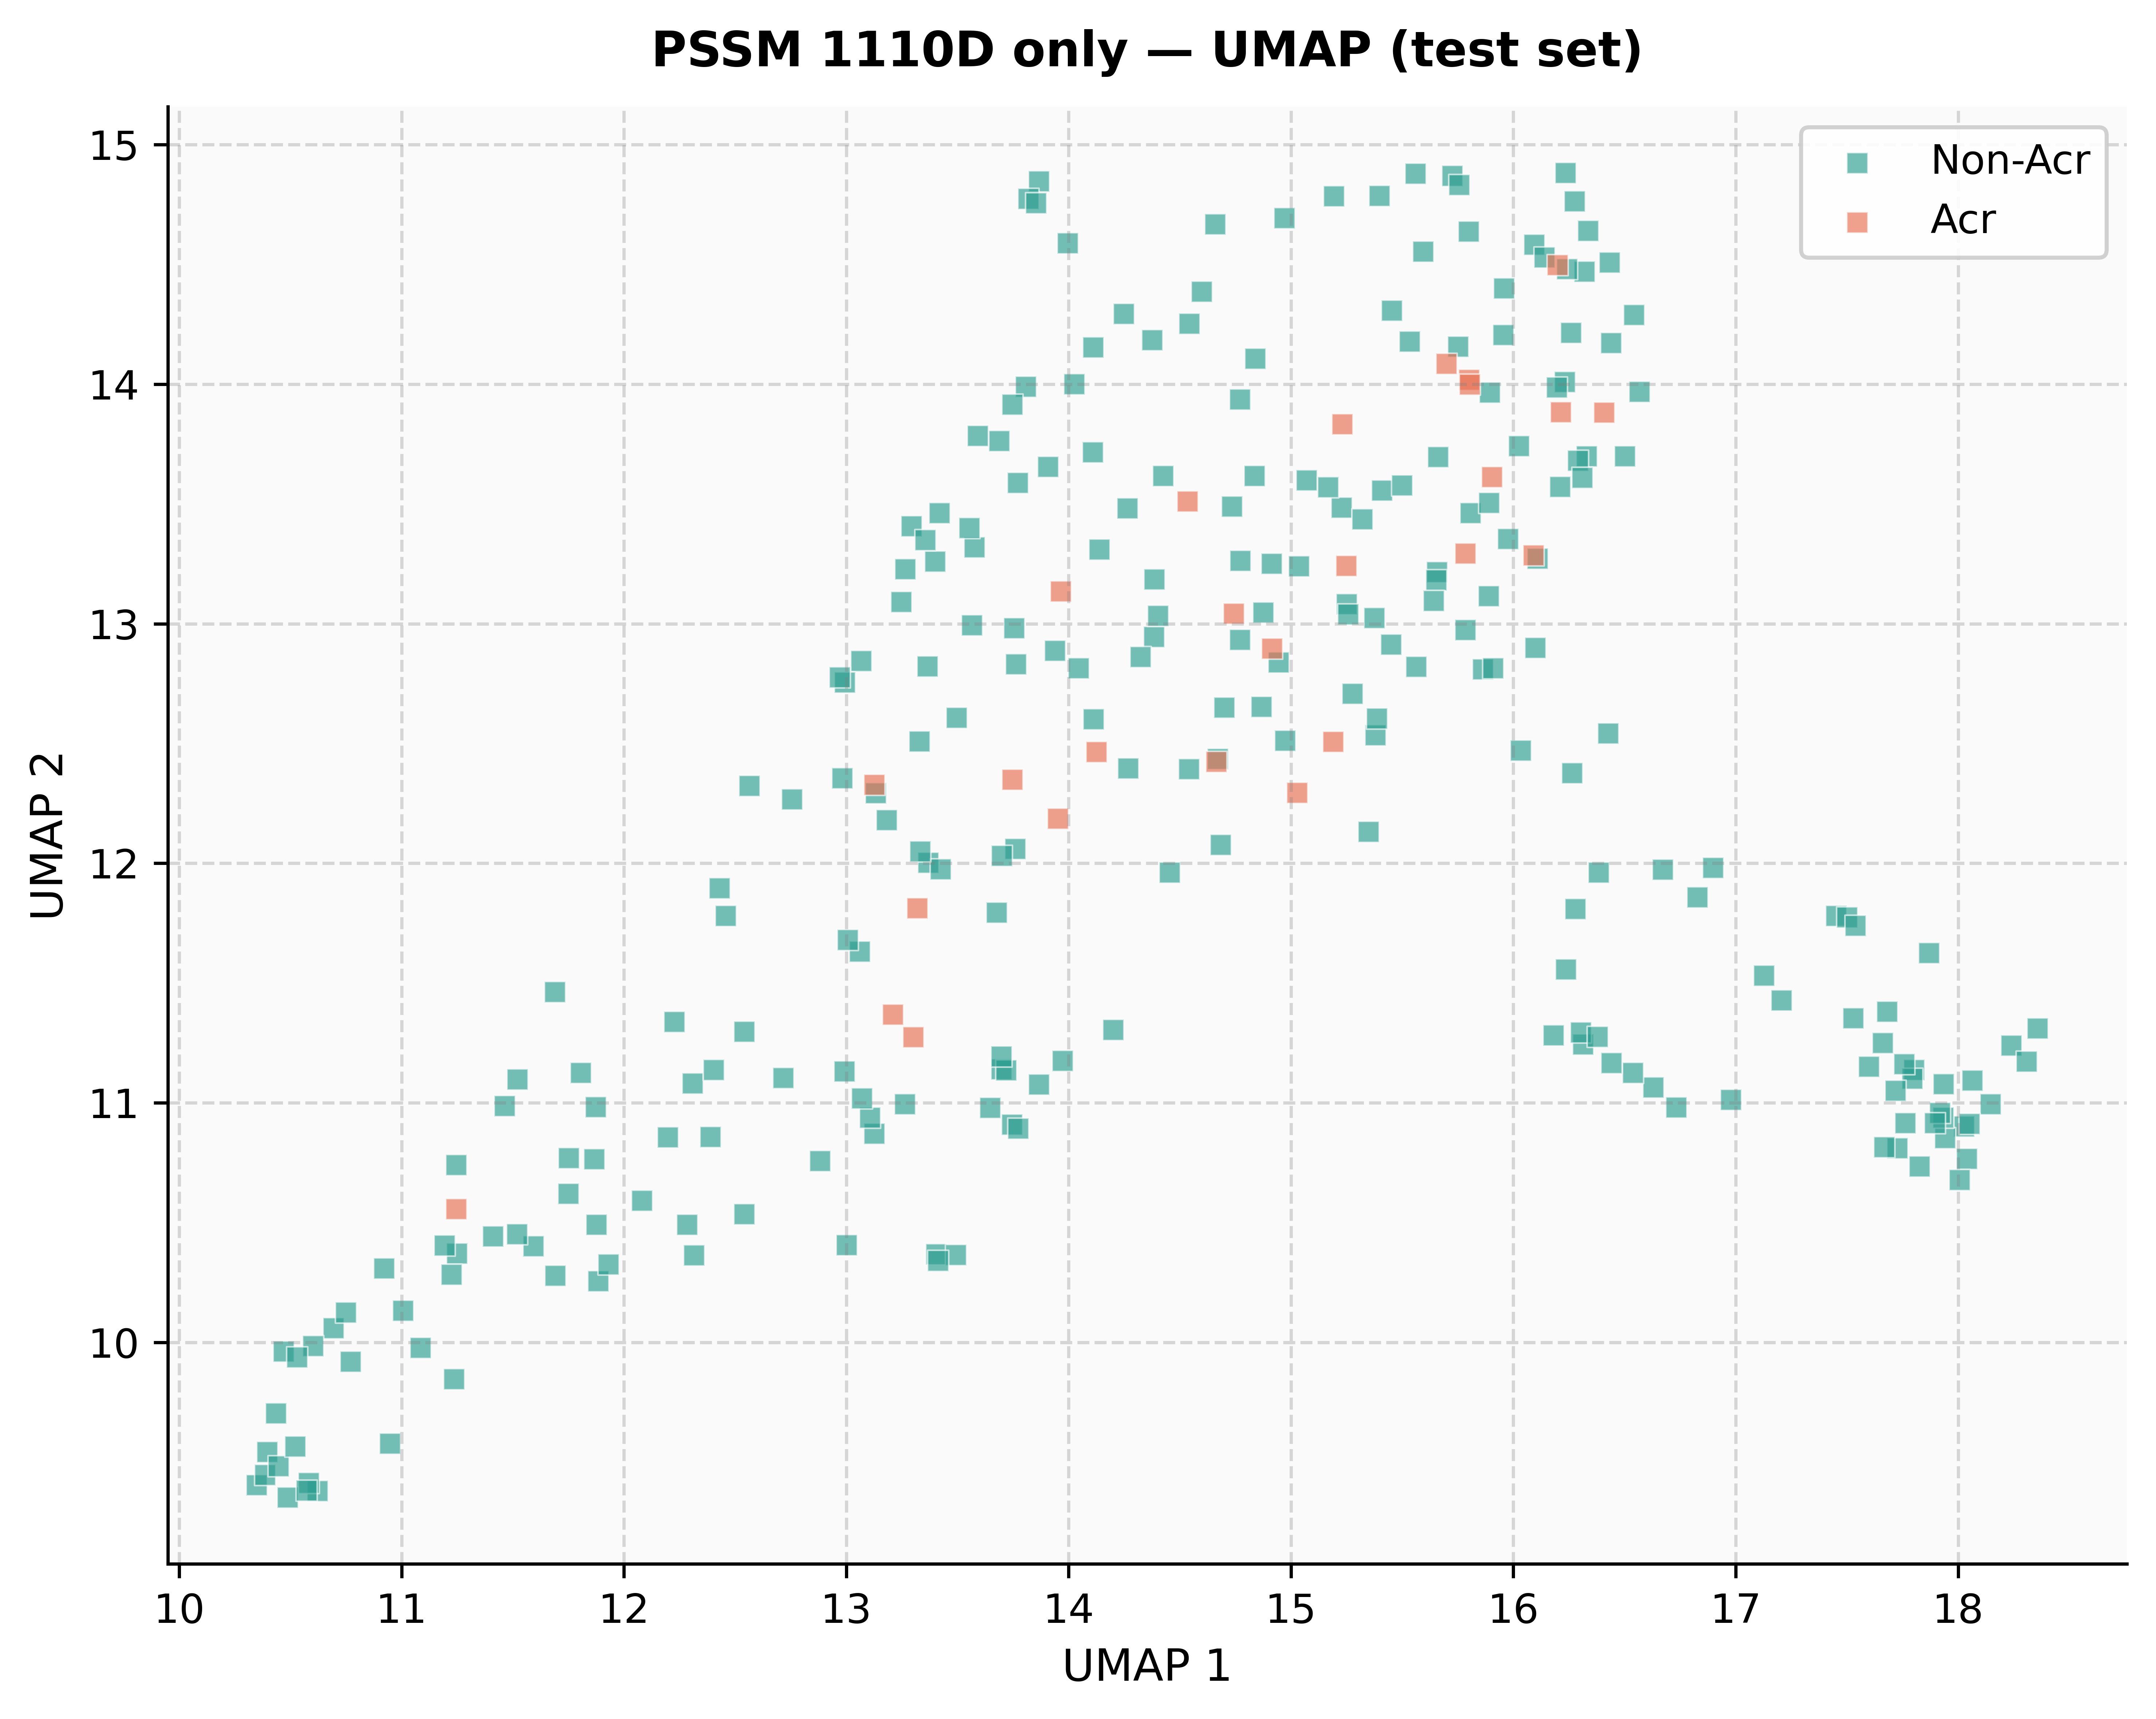

In [6]:
from umap.umap_ import UMAP

umap_colors = {0: '#2A9D8F', 1: '#E76F51'}
umap_labels = {0: 'Non-Acr', 1: 'Acr'}

for split_name in ('train', 'valid', 'test'):
    X_s, y_s = splits[split_name]
    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=22)
    emb_2d = reducer.fit_transform(X_s)
    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, linestyle='--', alpha=0.3, color='grey')
    for l in [0, 1]:
        mask = y_s == l
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=umap_colors[l], marker='s', s=28, alpha=0.65,
                   edgecolors='white', linewidths=0.4, label=umap_labels[l])
    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.set_ylabel('UMAP 2', fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#CCCCCC')
    ax.set_title(f'PSSM {PSSM_DIM}D only \u2014 UMAP ({split_name} set)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_ROOT, 'notebooks',
                f'pssm_umap_{split_name}.png'), dpi=PLOT_DPI, bbox_inches='tight')
    plt.show()
